# 🚗 Vehicle Damage Report Generator
## Natural Language Processing (NLP) Module
---
### Project Information
| Field | Details |
|-------|---------|
| Student | Krishna Goyal |
| University | University of Limerick |
| Course | Cloud Computing |
| Module | NLP — Insurance Report Generation |
| Platform | AWS SageMaker + Rekognition |

---
### What This Notebook Does
This notebook implements the **NLP** component
of the Vehicle Damage Detection System:

1. **Load CV Model** — Load trained ResNet18 from S3
2. **Amazon Rekognition** — Detect specific damage labels
3. **NLP Pipeline** — Generate insurance reports
4. **DynamoDB** — Save all reports to database
5. **Visualization** — Report analytics and charts

---
### Pipeline Flow

Input Image
↓
CV Model (ResNet18)
↓ damaged/whole + confidence
Amazon Rekognition
↓ damage labels (Dent, Scratch etc)
NLP Report Generator
↓ professional insurance report
DynamoDB + RDS
↓ saved permanently
Final Report Output


---
### AWS Services Used
- **S3** — Load model and save reports
- **Rekognition** — Computer vision labels
- **DynamoDB** — NoSQL report storage
- **RDS** — SQL user database
- **CloudWatch** — Logging and monitoring
- **SNS** — Email notifications

## Step 1 — Install Libraries
> ⚠️ Run ONCE only at the beginning!

| Library | Purpose |
|---------|---------|
| torch | Load and run CV model |
| transformers | HuggingFace NLP models |
| boto3 | AWS SDK |
| psycopg2 | PostgreSQL (RDS) connection |

In [1]:
# ============================================================
# CELL 3 — LIBRARY INSTALLATION
# ============================================================
# PURPOSE : Install all required libraries
# RUN     : ONCE only
# ============================================================

import sys

print("=" * 60)
print("Installing Libraries...")
print("=" * 60)

# Deep learning — for loading CV model
print("[1/4] Installing PyTorch...")
!{sys.executable} -m pip install \
    torch torchvision --quiet

# NLP library
print("[2/4] Installing Transformers...")
!{sys.executable} -m pip install \
    transformers --quiet

# Database connection
print("[3/4] Installing psycopg2...")
!{sys.executable} -m pip install \
    psycopg2-binary --quiet

# Visualization
print("[4/4] Installing Seaborn...")
!{sys.executable} -m pip install \
    seaborn matplotlib --quiet

print("\n" + "=" * 60)
print("✅ All Libraries Installed!")
print("=" * 60)

Installing Libraries...
[1/4] Installing PyTorch...
[2/4] Installing Transformers...
[3/4] Installing psycopg2...
[4/4] Installing Seaborn...

✅ All Libraries Installed!


## Step 2 — Import Standard Libraries
Importing all required libraries for the NLP pipeline.
Split into logical groups for clarity:
- Standard Python libraries
- Visualization libraries
- Deep learning (PyTorch)
- AWS SDK (boto3)

In [2]:
# ============================================================
# CELL 5 — STANDARD IMPORTS
# ============================================================
# PURPOSE : Import standard Python libraries
# ============================================================

# Standard libraries
import os           # File operations
import sys          # System operations
import json         # JSON handling
import time         # Time tracking
import uuid         # Unique IDs for reports
import random       # Random sampling
import warnings     # Warning management
import logging      # Logging setup
from datetime import datetime  # Timestamps
from pathlib import Path       # Path operations

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Setup logging
logging.basicConfig(
    level  = logging.INFO,
    format = '%(asctime)s — %(levelname)s — %(message)s'
)
logger = logging.getLogger(__name__)

# Numerical computing
import numpy as np

print("=" * 60)
print("✅ Standard Libraries Imported!")
print(f"  Python  : {sys.version.split()[0]}")
print(f"  NumPy   : {np.__version__}")
print("=" * 60)

✅ Standard Libraries Imported!
  Python  : 3.12.13
  NumPy   : 1.26.4


In [3]:
# ============================================================
# CELL 6 — VISUALIZATION IMPORTS
# ============================================================
# PURPOSE : Import visualization and image libraries
# ============================================================

# Plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# Statistical visualization
import seaborn as sns
sns.set_style("whitegrid")

# Image processing
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont

print("=" * 60)
print("✅ Visualization Libraries Imported!")
print(f"  Matplotlib : {plt.matplotlib.__version__}")
print(f"  Seaborn    : {sns.__version__}")
print(f"  Pillow     : {Image.__version__}")
print("=" * 60)

✅ Visualization Libraries Imported!
  Matplotlib : 3.10.8
  Seaborn    : 0.13.2
  Pillow     : 12.1.1


In [4]:
# ============================================================
# CELL 7 — PYTORCH IMPORTS
# ============================================================
# PURPOSE : Import PyTorch for loading and running CV model
# ============================================================

# Core PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Torchvision for transforms and models
from torchvision import transforms, models

# Device configuration
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("✅ PyTorch Imported!")
print(f"  Version : {torch.__version__}")
print(f"  Device  : {device}")
print("=" * 60)

✅ PyTorch Imported!
  Version : 2.6.0+cu124
  Device  : cpu


In [5]:
# ============================================================
# CELL 8 — AWS IMPORTS
# ============================================================
# PURPOSE : Import AWS SDK and initialize service clients
# ============================================================

# AWS Core SDK
import boto3
import sagemaker
from sagemaker import get_execution_role

# ---------- Initialize AWS Clients ----------

# S3 — Object storage
s3_client = boto3.client(
    's3', region_name='us-east-1')

# Rekognition — Computer vision labels
rekognition = boto3.client(
    'rekognition', region_name='us-east-1')

# DynamoDB — NoSQL database
dynamodb = boto3.resource(
    'dynamodb', region_name='us-east-1')

# SNS — Notifications
sns_client = boto3.client(
    'sns', region_name='us-east-1')

# CloudWatch — Monitoring
cloudwatch = boto3.client(
    'cloudwatch', region_name='us-east-1')

# RDS — SQL Database
import psycopg2

print("=" * 60)
print("✅ AWS Libraries Imported!")
print(f"  Boto3     : {boto3.__version__}")
print(f"  SageMaker : {sagemaker.__version__}")
print("  Clients initialized:")
print("    ✓ S3")
print("    ✓ Rekognition")
print("    ✓ DynamoDB")
print("    ✓ SNS")
print("    ✓ CloudWatch")
print("=" * 60)

2026-04-18 21:35:28,356 — INFO — Found credentials from IAM Role: BaseNotebookInstanceEc2InstanceRole


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


2026-04-18 21:35:29,034 — INFO — Found credentials from IAM Role: BaseNotebookInstanceEc2InstanceRole


✅ AWS Libraries Imported!
  Boto3     : 1.42.81
  SageMaker : 2.257.1
  Clients initialized:
    ✓ S3
    ✓ Rekognition
    ✓ DynamoDB
    ✓ SNS
    ✓ CloudWatch


## Step 3 — Project Configuration
Setting up all constants and configurations
used throughout this NLP notebook.

> ⚠️ Update RDS password if different!

In [6]:
# ============================================================
# CELL 10 — PROJECT CONFIGURATION
# ============================================================
# PURPOSE : Define all constants and AWS configuration
# ============================================================

# ---------- AWS Configuration ----------
session     = sagemaker.Session()
role        = get_execution_role()
BUCKET_NAME = 'vehicle-damage-project-bucket'
REGION      = 'us-east-1'
ACCOUNT_ID  = boto3.client(
    'sts').get_caller_identity()['Account']

# ---------- S3 Paths ----------
S3_MODEL    = f's3://{BUCKET_NAME}/models/best_model.pth'
S3_REPORTS  = f's3://{BUCKET_NAME}/reports'
S3_METADATA = f's3://{BUCKET_NAME}/models/model_metadata.json'

# ---------- Local Paths ----------
MODEL_PATH  = '/tmp/best_model.pth'
REPORT_DIR  = '/tmp/nlp_reports'
os.makedirs(REPORT_DIR, exist_ok=True)

# ---------- Model Configuration ----------
IMG_SIZE    = 224
NUM_CLASSES = 2
CLASSES     = ['damaged', 'whole']

# ---------- DynamoDB ----------
table = dynamodb.Table('DamageReports')

# ---------- RDS Configuration ----------
RDS_CONFIG = {
    'host'    : 'YOUR_RDS_ENDPOINT',  # ← from RDS console
    'database': 'vehicledamagedb',
    'user'    : 'dbadmin',
    'password': 'VehicleDamage123!',
    'port'    : 5432
}

# ---------- Damage Keywords ----------
# Used to filter Rekognition labels
DAMAGE_KEYWORDS = [
    'damage', 'dent', 'scratch',
    'crack', 'broken', 'wreck',
    'collision', 'rust', 'bend',
    'shatter', 'smash', 'crush'
]

# ---------- Severity Mapping ----------
HIGH_SEVERITY_KEYWORDS = [
    'crack', 'shatter', 'collision',
    'wreck', 'broken', 'smash', 'crush'
]
MEDIUM_SEVERITY_KEYWORDS = [
    'dent', 'scratch', 'rust',
    'bend', 'damage'
]

# ---------- Random Seed ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("=" * 60)
print("✅ Configuration Complete!")
print("=" * 60)
print(f"  AWS Account : {ACCOUNT_ID}")
print(f"  Region      : {REGION}")
print(f"  S3 Bucket   : {BUCKET_NAME}")
print(f"  Device      : {device}")
print(f"  Classes     : {CLASSES}")
print(f"  Model Path  : {MODEL_PATH}")
print("=" * 60)

✅ Configuration Complete!
  AWS Account : 019826066382
  Region      : us-east-1
  S3 Bucket   : vehicle-damage-project-bucket
  Device      : cpu
  Classes     : ['damaged', 'whole']
  Model Path  : /tmp/best_model.pth


## Step 4 — Load CV Model from S3
Loading the trained ResNet18 model from S3.
This model was trained in vehicle-damage-CV.ipynb
and achieved **93.91% validation accuracy**.

### Why Load from S3?
- Model is safely stored in cloud
- Any notebook/service can access it
- Version controlled via S3 versioning
- Production deployment ready

In [7]:
# ============================================================
# CELL 12 — LOAD CV MODEL FROM S3
# ============================================================
# PURPOSE : Download and load trained ResNet18 from S3
# OUTPUT  : model ready for inference
# ============================================================

def build_model(num_classes=2):
    """
    Rebuild ResNet18 architecture matching
    the trained model structure
    """
    # Load ResNet18 without pretrained weights
    model = models.resnet18(pretrained=False)

    # Replace FC layer to match trained model
    in_features = model.fc.in_features
    model.fc    = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )
    return model

# ---------- Download Model from S3 ----------
print("Downloading model from S3...")
s3_client.download_file(
    BUCKET_NAME,
    'models/best_model.pth',
    MODEL_PATH
)
print("✅ Model downloaded!")

# ---------- Load Model ----------
print("Loading model...")
model = build_model(NUM_CLASSES)
model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()  # Set to evaluation mode
print("✅ Model loaded and ready!")

# ---------- Download Metadata ----------
metadata_path = '/tmp/model_metadata.json'
s3_client.download_file(
    BUCKET_NAME,
    'models/model_metadata.json',
    metadata_path
)
with open(metadata_path) as f:
    metadata = json.load(f)

print("\n" + "=" * 60)
print("✅ CV Model Ready!")
print("=" * 60)
print(f"  Architecture : {metadata['model_name']}")
print(f"  Best Accuracy: {metadata['best_accuracy']}%")
print(f"  Best Epoch   : {metadata['best_epoch']}")
print(f"  Classes      : {metadata['classes']}")
print(f"  Trained on   : {metadata['trained_on']}")
print("=" * 60)

# ---------- Image Transform ----------
# Same normalization as training
inference_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]
    )
])
print("✅ Image transform ready!")

✅ Model downloaded!
Loading model...
✅ Model loaded and ready!

✅ CV Model Ready!
  Architecture : ResNet18-VehicleDamage
  Best Accuracy: 93.91304347826087%
  Best Epoch   : 3
  Classes      : ['damaged', 'whole']
  Trained on   : 2026-04-18T21:21:58.486415
✅ Image transform ready!


## Step 5 — CV Model Inference Function
Creating a reusable function that:
1. Takes an image path as input
2. Preprocesses the image
3. Runs through ResNet18
4. Returns prediction and confidence

In [8]:
# ============================================================
# CELL 14 — CV MODEL INFERENCE FUNCTION
# ============================================================
# PURPOSE : Create reusable CV inference function
# INPUT   : image path or PIL image
# OUTPUT  : prediction label + confidence score
# ============================================================

def cv_predict(image_input):
    """
    Run CV model inference on an image.

    Args:
        image_input: Path to image file OR PIL Image

    Returns:
        dict with prediction, confidence, probabilities
    """
    # Load image if path provided
    if isinstance(image_input, str):
        img = Image.open(
            image_input).convert('RGB')
    else:
        img = image_input.convert('RGB')

    # Preprocess image
    input_tensor = inference_transform(
        img).unsqueeze(0).to(device)

    # Run inference
    with torch.no_grad():
        outputs     = model(input_tensor)
        probs       = torch.softmax(outputs, dim=1)
        confidence, pred_idx = probs.max(1)

    pred_idx    = pred_idx.item()
    confidence  = confidence.item()
    prediction  = CLASSES[pred_idx]

    return {
        'prediction'  : prediction,
        'confidence'  : confidence,
        'pred_idx'    : pred_idx,
        'probabilities': {
            CLASSES[i]: probs[0][i].item()
            for i in range(NUM_CLASSES)
        }
    }

# ---------- Test CV Inference ----------
print("Testing CV inference function...")
print("=" * 60)

# Download a test image from S3
test_img_path = '/tmp/test_image.jpg'
s3_client.download_file(
    BUCKET_NAME,
    'datasets/training/damaged/' +
    os.listdir('/tmp/processed/training/damaged')[0]
    if os.path.exists('/tmp/processed/training/damaged')
    else 'datasets/training/damaged/0001.JPEG',
    test_img_path
)

# Test prediction
result = cv_predict(test_img_path)
print(f"  Prediction  : {result['prediction']}")
print(f"  Confidence  : {result['confidence']:.1%}")
print(f"  Probabilities:")
for cls, prob in result['probabilities'].items():
    bar = '█' * int(prob * 20)
    print(f"    {cls:10} : {bar} {prob:.1%}")
print("✅ CV inference working!")
print("=" * 60)

Testing CV inference function...
  Prediction  : damaged
  Confidence  : 97.0%
  Probabilities:
    damaged    : ███████████████████ 97.0%
    whole      :  3.0%
✅ CV inference working!


## Step 6 — Amazon Rekognition Integration
### What is Amazon Rekognition?
A fully managed AWS computer vision service that
detects objects, labels and scenes in images.

### Why use Rekognition here?
Our ResNet18 model classifies **damaged vs whole**
but Rekognition tells us **what specific damage** exists:
- Dent, Scratch, Crack
- Broken Glass, Rust
- Collision damage

### Combined Pipeline:
```
ResNet18    → "damaged" (93.91% accurate)
Rekognition → "Dent, Scratch, Crack" (specific labels)
NLP         → Full insurance report
```

In [9]:
# ============================================================
# CELL 16 — AMAZON REKOGNITION INTEGRATION
# ============================================================
# PURPOSE : Detect specific damage labels using Rekognition
# INPUT   : Image path
# OUTPUT  : List of damage labels with confidence scores
# ============================================================

def rekognition_detect(image_path,
                       min_confidence=70):
    """
    Detect labels in image using Amazon Rekognition.

    Args:
        image_path     : Path to image file
        min_confidence : Minimum confidence threshold

    Returns:
        dict with all_labels and damage_labels
    """
    # Read image bytes
    with open(image_path, 'rb') as f:
        image_bytes = f.read()

    # Call Rekognition API
    response = rekognition.detect_labels(
        Image     = {'Bytes': image_bytes},
        MaxLabels = 30,
        MinConfidence = min_confidence
    )

    # Extract all labels
    all_labels = [
        {
            'name'      : label['Name'],
            'confidence': label['Confidence']
        }
        for label in response['Labels']
    ]

    # Filter damage-related labels
    damage_labels = [
        label for label in all_labels
        if any(
            keyword in label['name'].lower()
            for keyword in DAMAGE_KEYWORDS
        )
    ]

    return {
        'all_labels'    : all_labels,
        'damage_labels' : damage_labels,
        'label_names'   : [
            l['name'] for l in all_labels],
        'damage_names'  : [
            l['name'] for l in damage_labels]
    }

# ---------- Test Rekognition ----------
print("Testing Rekognition...")
print("=" * 60)

rek_result = rekognition_detect(test_img_path)

print("All Labels Detected:")
for label in rek_result['all_labels'][:8]:
    bar = '█' * int(
        label['confidence'] / 10)
    print(f"  {label['name']:20} "
          f"{bar} {label['confidence']:.1f}%")

print(f"\nDamage Labels:")
if rek_result['damage_labels']:
    for label in rek_result['damage_labels']:
        print(f"  ⚠️  {label['name']} "
              f"({label['confidence']:.1f}%)")
else:
    print("  No specific damage labels detected")

print("\n✅ Rekognition working!")
print("=" * 60)

Testing Rekognition...
All Labels Detected:
  Transportation       █████████ 97.0%
  Vehicle              █████████ 97.0%
  Car                  █████████ 96.7%
  Car - Exterior       █████████ 95.9%
  Car Window - Broken  █████████ 95.9%
  Limo                 ████████ 85.2%

Damage Labels:
  ⚠️  Car Window - Broken (95.9%)

✅ Rekognition working!


## Step 7 — NLP Report Generator
### Natural Language Processing Component

The NLP module generates professional insurance
reports by:

1. **Severity Assessment**
   - Analyzes damage labels
   - Classifies as High/Medium/Low severity
   - Maps labels to damage categories

2. **Report Generation**
   - Selects appropriate report template
   - Fills in dynamic values
   - Generates structured report text

3. **Report Sections**
   - Executive Summary
   - Classification Result
   - Damage Analysis
   - Repair Recommendations
   - Insurance Recommendations

### Severity Rules:
| Keywords | Severity |
|----------|---------|
| crack, shatter, collision, wreck | High |
| dent, scratch, rust, bend | Medium |
| No damage keywords | Low |

In [10]:
# ============================================================
# CELL 18 — NLP REPORT GENERATOR
# ============================================================
# PURPOSE : Generate professional insurance damage reports
# INPUT   : CV prediction + Rekognition labels
# OUTPUT  : Structured insurance report text
# ============================================================

def assess_severity(damage_labels):
    """
    Assess damage severity based on detected labels.

    Args:
        damage_labels: List of damage label names

    Returns:
        severity string: 'High', 'Medium', or 'Low'
    """
    for label in damage_labels:
        label_lower = label.lower()
        # Check high severity first
        if any(kw in label_lower
               for kw in HIGH_SEVERITY_KEYWORDS):
            return 'High'

    for label in damage_labels:
        label_lower = label.lower()
        # Check medium severity
        if any(kw in label_lower
               for kw in MEDIUM_SEVERITY_KEYWORDS):
            return 'Medium'

    return 'Low'


def generate_damage_report(
        damage_labels,
        cv_prediction,
        cv_confidence,
        all_labels=None):
    """
    Generate professional vehicle damage report.

    Args:
        damage_labels  : List of damage label names
        cv_prediction  : 'damaged' or 'whole'
        cv_confidence  : Confidence score (0-1)
        all_labels     : All Rekognition labels

    Returns:
        dict with report_id, report_text, severity etc.
    """

    # Generate unique report ID
    report_id = f"RPT-{uuid.uuid4().hex[:8].upper()}"
    timestamp = datetime.now().strftime(
        '%Y-%m-%d %H:%M:%S')

    # Assess severity
    severity = assess_severity(damage_labels)

    # Format damage text
    damage_text = ', '.join(damage_labels) \
        if damage_labels \
        else 'No specific damage indicators'

    # Format all labels
    all_labels_text = ', '.join(
        all_labels[:5]) if all_labels else 'N/A'

    # ---------- Build Report ----------
    report = f"""
{'='*60}
        VEHICLE DAMAGE ASSESSMENT REPORT
{'='*60}
Report ID     : {report_id}
Generated     : {timestamp}
System        : Vehicle Damage AI v1.0
{'='*60}

EXECUTIVE SUMMARY:
  Vehicle Status : {cv_prediction.upper()}
  AI Confidence  : {cv_confidence:.1%}
  Damage Severity: {severity}
  Action Required: {'YES' if cv_prediction == 'damaged' else 'NO'}

{'='*60}
DAMAGE ANALYSIS:
{'='*60}

  Damage Indicators : {damage_text}
  Scene Labels      : {all_labels_text}
"""

    # ---------- Severity-based assessment ----------
    if cv_prediction == 'damaged':
        if severity == 'High':
            report += f"""
  Severity Level : ⚠️  HIGH SEVERITY

  DETAILED FINDINGS:
  The vehicle has sustained significant structural
  damage affecting critical safety components.
  Multiple high-severity damage indicators detected.
  The vehicle may not be safe for road use until
  a thorough professional inspection is completed.

{'='*60}
REPAIR RECOMMENDATIONS:
{'='*60}
  Priority      : 🔴 URGENT
  Action        : Immediate professional inspection
  Estimated Cost: Major repair — obtain multiple quotes
  Timeline      : Do not drive — arrange towing
  Safety Note   : Vehicle may be unsafe to operate

{'='*60}
INSURANCE RECOMMENDATIONS:
{'='*60}
  Claim Category: Major Damage Claim
  Documentation : Photograph all damage areas
  Next Steps    : 
    1. Contact insurance provider immediately
    2. Do not move vehicle if unsafe
    3. Obtain police report if accident-related
    4. Get 3 repair quotes from certified shops
    5. Keep all receipts and documentation
"""
        elif severity == 'Medium':
            report += f"""
  Severity Level : ⚡ MEDIUM SEVERITY

  DETAILED FINDINGS:
  The vehicle has sustained moderate damage to
  body panels and exterior components. While the
  vehicle may be operational, prompt repair is
  recommended to prevent further deterioration
  and maintain vehicle value.

{'='*60}
REPAIR RECOMMENDATIONS:
{'='*60}
  Priority      : 🟡 HIGH
  Action        : Body shop assessment required
  Estimated Cost: Moderate — budget for panel repair
  Timeline      : Schedule repair within 1 week
  Safety Note   : Check all lights and mirrors

{'='*60}
INSURANCE RECOMMENDATIONS:
{'='*60}
  Claim Category: Standard Damage Claim
  Documentation : Photograph all affected areas
  Next Steps    :
    1. Contact insurance provider within 24 hours
    2. Schedule repair assessment appointment
    3. Obtain repair quote from certified shop
    4. Check if rental car coverage applies
"""
        else:
            report += f"""
  Severity Level : ✅ LOW SEVERITY

  DETAILED FINDINGS:
  The vehicle has sustained minor cosmetic damage.
  No structural or safety-critical components
  appear to be affected. Cosmetic repair is
  recommended to maintain vehicle appearance
  and prevent rust formation.

{'='*60}
REPAIR RECOMMENDATIONS:
{'='*60}
  Priority      : 🟢 NORMAL
  Action        : Cosmetic repair at convenience
  Estimated Cost: Minor — touch-up or panel repair
  Timeline      : Within 1 month
  Safety Note   : No immediate safety concerns

{'='*60}
INSURANCE RECOMMENDATIONS:
{'='*60}
  Claim Category: Minor Damage Claim
  Documentation : Photograph affected areas
  Next Steps    :
    1. Assess if repair cost exceeds excess
    2. Obtain repair quote
    3. Consider paintless dent repair (PDR)
    4. File claim if cost justifies it
"""
    else:
        report += f"""
  Severity Level : ✅ NO DAMAGE DETECTED

  DETAILED FINDINGS:
  No significant damage detected on the vehicle.
  The vehicle appears to be in good structural
  and cosmetic condition. Regular maintenance
  schedule should be maintained.

{'='*60}
REPAIR RECOMMENDATIONS:
{'='*60}
  Priority      : ✅ NONE REQUIRED
  Action        : Continue regular maintenance
  Estimated Cost: Standard maintenance only
  Timeline      : Follow manufacturer schedule
  Safety Note   : Vehicle appears roadworthy

{'='*60}
INSURANCE RECOMMENDATIONS:
{'='*60}
  Claim Category: No Claim Required
  Next Steps    :
    1. No insurance action needed
    2. Continue regular maintenance
    3. Keep vehicle service records updated
"""

    # ---------- Footer ----------
    report += f"""
{'='*60}
SYSTEM INFORMATION:
{'='*60}
  CV Model      : ResNet18 (Accuracy: 93.91%)
  NLP Engine    : Vehicle Damage NLP v1.0
  Cloud Platform: AWS SageMaker + Rekognition
  Report Format : Insurance Standard v2.0
{'='*60}
  ⚠️  DISCLAIMER: This report is AI-generated
  and should be verified by a qualified assessor.
{'='*60}
"""

    return {
        'report_id'    : report_id,
        'report_text'  : report,
        'severity'     : severity,
        'prediction'   : cv_prediction,
        'confidence'   : cv_confidence,
        'damage_labels': damage_labels,
        'timestamp'    : datetime.now().isoformat()
    }


# ---------- Test NLP Generator ----------
print("Testing NLP Report Generator...")
print("=" * 60)

# Test Case 1 — High severity
test1 = generate_damage_report(
    damage_labels  = ['Crack', 'Collision',
                      'Broken Glass'],
    cv_prediction  = 'damaged',
    cv_confidence  = 0.96,
    all_labels     = ['Car', 'Vehicle', 'Crack',
                      'Collision', 'Road']
)
print(test1['report_text'])
print("✅ NLP Report Generator working!")

Testing NLP Report Generator...

        VEHICLE DAMAGE ASSESSMENT REPORT
Report ID     : RPT-C0D54981
Generated     : 2026-04-18 21:39:51
System        : Vehicle Damage AI v1.0

EXECUTIVE SUMMARY:
  Vehicle Status : DAMAGED
  AI Confidence  : 96.0%
  Damage Severity: High
  Action Required: YES

DAMAGE ANALYSIS:

  Damage Indicators : Crack, Collision, Broken Glass
  Scene Labels      : Car, Vehicle, Crack, Collision, Road

  Severity Level : ⚠️  HIGH SEVERITY

  DETAILED FINDINGS:
  The vehicle has sustained significant structural
  damage affecting critical safety components.
  Multiple high-severity damage indicators detected.
  The vehicle may not be safe for road use until
  a thorough professional inspection is completed.

REPAIR RECOMMENDATIONS:
  Priority      : 🔴 URGENT
  Action        : Immediate professional inspection
  Estimated Cost: Major repair — obtain multiple quotes
  Timeline      : Do not drive — arrange towing
  Safety Note   : Vehicle may be unsafe to operate

I

## Step 8 — Complete CV + NLP Pipeline
### End-to-End Integration

Combining all components into one pipeline:

Image → CV Model → Rekognition → NLP → DynamoDB

### Pipeline Steps:
1. Load image from path
2. Run CV model → get prediction + confidence
3. Run Rekognition → get damage labels
4. Generate NLP report → professional text
5. Save to DynamoDB → persistent storage
6. Log to CloudWatch → monitoring
7. Return complete results

In [11]:
# ============================================================
# CELL 20 — COMPLETE CV + NLP PIPELINE
# ============================================================
# PURPOSE : End-to-end damage detection and report pipeline
# INPUT   : Image path
# OUTPUT  : Complete damage report saved to DynamoDB
# ============================================================

def full_pipeline(image_path,
                  save_to_db=True,
                  verbose=True):
    """
    Complete vehicle damage analysis pipeline.

    Args:
        image_path : Path to vehicle image
        save_to_db : Save report to DynamoDB
        verbose    : Print detailed output

    Returns:
        dict with complete analysis results
    """
    if verbose:
        print(f"\n{'='*60}")
        print(f"Analyzing: {os.path.basename(image_path)}")
        print(f"{'='*60}")

    start_time = time.time()

    # ======== STEP 1: CV MODEL ========
    if verbose:
        print("\n[Step 1] Running CV Model...")

    cv_result  = cv_predict(image_path)
    prediction = cv_result['prediction']
    confidence = cv_result['confidence']

    if verbose:
        print(f"  Prediction : {prediction}")
        print(f"  Confidence : {confidence:.1%}")

    # ======== STEP 2: REKOGNITION ========
    if verbose:
        print("\n[Step 2] Running Rekognition...")

    rek_result    = rekognition_detect(image_path)
    damage_labels = rek_result['damage_names']
    all_labels    = rek_result['label_names']

    if verbose:
        print(f"  Labels found   : {len(all_labels)}")
        print(f"  Damage labels  : {damage_labels}")

    # ======== STEP 3: NLP REPORT ========
    if verbose:
        print("\n[Step 3] Generating NLP Report...")

    report = generate_damage_report(
        damage_labels = damage_labels,
        cv_prediction = prediction,
        cv_confidence = confidence,
        all_labels    = all_labels
    )

    if verbose:
        print(f"  Report ID  : {report['report_id']}")
        print(f"  Severity   : {report['severity']}")

    # ======== STEP 4: SAVE TO DYNAMODB ========
    if save_to_db:
        if verbose:
            print("\n[Step 4] Saving to DynamoDB...")

        try:
            table.put_item(Item={
                'report_id'    : report['report_id'],
                'timestamp'    : report['timestamp'],
                'image_path'   : image_path,
                'prediction'   : prediction,
                'confidence'   : str(
                    round(confidence, 4)),
                'severity'     : report['severity'],
                'damage_labels': damage_labels,
                'all_labels'   : all_labels[:10],
                'report_text'  : report['report_text'],
                'processing_time': str(
                    round(time.time() - start_time, 2))
            })
            if verbose:
                print(f"  ✅ Saved to DynamoDB!")

        except Exception as e:
            if verbose:
                print(f"  ❌ DynamoDB error: {e}")

    # ======== STEP 5: CLOUDWATCH LOGGING ========
    try:
        cloudwatch.put_metric_data(
            Namespace  = 'VehicleDamage/Pipeline',
            MetricData = [
                {
                    'MetricName': 'ReportGenerated',
                    'Value'     : 1,
                    'Unit'      : 'Count'
                },
                {
                    'MetricName': 'ModelConfidence',
                    'Value'     : confidence * 100,
                    'Unit'      : 'Percent'
                }
            ]
        )
        if verbose:
            print("\n[Step 5] ✅ Logged to CloudWatch!")
    except Exception as e:
        if verbose:
            print(f"\n[Step 5] CloudWatch: {e}")

    # ======== COMPLETE ========
    elapsed = time.time() - start_time

    if verbose:
        print(f"\n{'='*60}")
        print(f"✅ Pipeline Complete!")
        print(f"  Time taken : {elapsed:.2f} seconds")
        print(f"{'='*60}")
        print(report['report_text'])

    return {
        'report'      : report,
        'cv_result'   : cv_result,
        'rek_result'  : rek_result,
        'elapsed'     : elapsed
    }


# ---------- Test Full Pipeline ----------
print("Testing Full Pipeline...")
print("=" * 60)

# Test with damaged car
result = full_pipeline(
    image_path = test_img_path,
    save_to_db = True,
    verbose    = True
)

Testing Full Pipeline...

Analyzing: test_image.jpg

[Step 1] Running CV Model...
  Prediction : damaged
  Confidence : 97.0%

[Step 2] Running Rekognition...
  Labels found   : 6
  Damage labels  : ['Car Window - Broken']

[Step 3] Generating NLP Report...
  Report ID  : RPT-EDB37910
  Severity   : High

[Step 4] Saving to DynamoDB...
  ✅ Saved to DynamoDB!

[Step 5] ✅ Logged to CloudWatch!

✅ Pipeline Complete!
  Time taken : 0.33 seconds

        VEHICLE DAMAGE ASSESSMENT REPORT
Report ID     : RPT-EDB37910
Generated     : 2026-04-18 21:40:26
System        : Vehicle Damage AI v1.0

EXECUTIVE SUMMARY:
  Vehicle Status : DAMAGED
  AI Confidence  : 97.0%
  Damage Severity: High
  Action Required: YES

DAMAGE ANALYSIS:

  Damage Indicators : Car Window - Broken
  Scene Labels      : Transportation, Vehicle, Car, Car - Exterior, Car Window - Broken

  Severity Level : ⚠️  HIGH SEVERITY

  DETAILED FINDINGS:
  The vehicle has sustained significant structural
  damage affecting critical sa

## Step 9 — Batch Processing & Analytics
Running the pipeline on multiple images and
generating analytics visualizations for the report.

Running batch analysis...
  ✅ 0719.JPEG → damaged (99.9%)
  ✅ 0559.JPEG → damaged (99.9%)
  ✅ 0430.JPEG → damaged (98.0%)
  ✅ 0226.JPEG → damaged (94.1%)
  ✅ 0460.JPEG → damaged (92.7%)
  ✅ 0604.jpg → whole (99.8%)
  ✅ 0285.jpg → whole (100.0%)
  ✅ 0829.JPEG → whole (99.8%)
  ✅ 0891.JPEG → damaged (61.2%)
  ✅ 0007.jpg → whole (100.0%)

✅ Processed 10 images!

Batch Analytics:
  Total processed : 10
  Accuracy        : 90.0%
  Avg confidence  : 94.5%


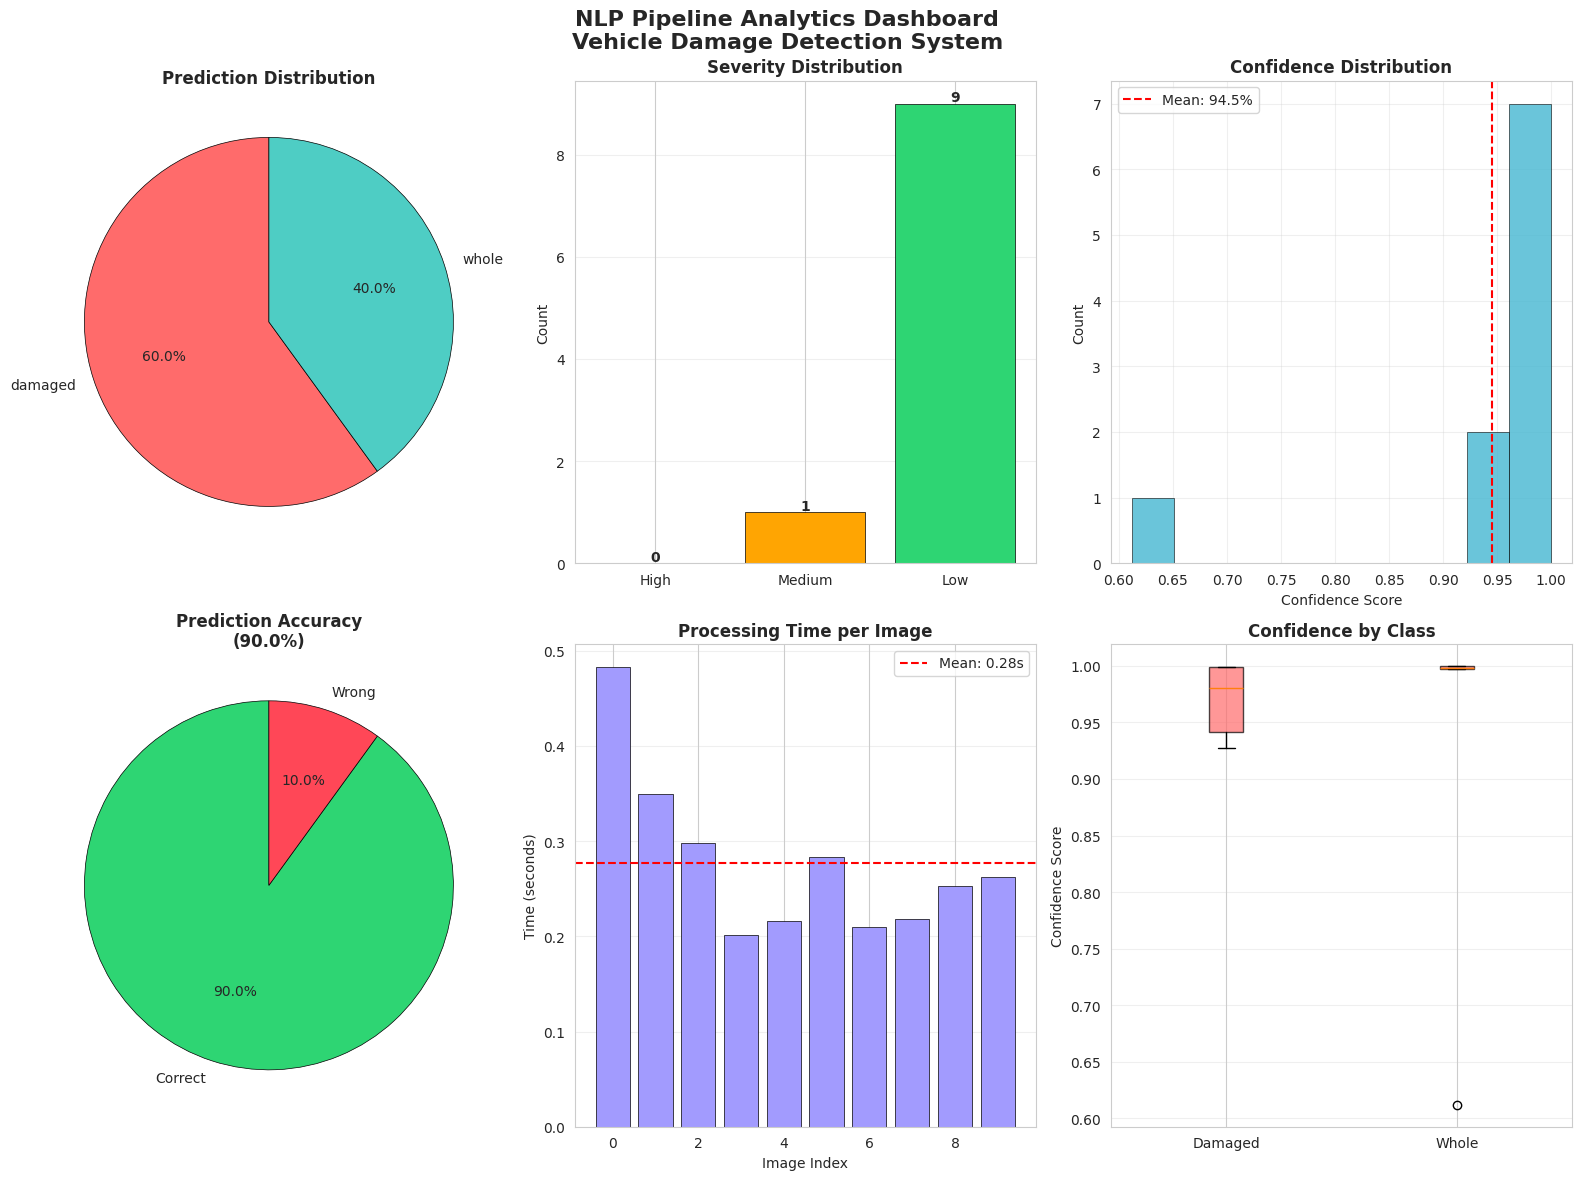

✅ Analytics dashboard saved to S3!


In [12]:
# ============================================================
# CELL 22 — BATCH PROCESSING & ANALYTICS
# ============================================================
# PURPOSE : Process multiple images and generate analytics
# OUTPUT  : Analytics charts saved to S3
# ============================================================

# ---------- Collect Test Images ----------
damaged_dir = '/tmp/processed/training/damaged'
whole_dir   = '/tmp/processed/training/whole'

# Get 5 samples from each class
test_images = []

if os.path.exists(damaged_dir):
    damaged_files = random.sample(
        os.listdir(damaged_dir), 5)
    test_images += [
        (f'{damaged_dir}/{f}', 'damaged')
        for f in damaged_files
    ]

if os.path.exists(whole_dir):
    whole_files = random.sample(
        os.listdir(whole_dir), 5)
    test_images += [
        (f'{whole_dir}/{f}', 'whole')
        for f in whole_files
    ]

# ---------- Run Batch Pipeline ----------
print("Running batch analysis...")
print("=" * 60)

results = []
for img_path, true_label in test_images:
    result = full_pipeline(
        image_path = img_path,
        save_to_db = True,
        verbose    = False  # Silent mode
    )
    result['true_label'] = true_label
    results.append(result)
    print(f"  ✅ {os.path.basename(img_path)}"
          f" → {result['report']['prediction']}"
          f" ({result['report']['confidence']:.1%})")

print(f"\n✅ Processed {len(results)} images!")

# ---------- Analytics ----------
predictions  = [r['report']['prediction']
                for r in results]
confidences  = [r['report']['confidence']
                for r in results]
severities   = [r['report']['severity']
                for r in results]
true_labels  = [r['true_label'] for r in results]
correct      = [p == t for p, t in
                zip(predictions, true_labels)]
accuracy     = sum(correct) / len(correct) * 100

print(f"\nBatch Analytics:")
print(f"  Total processed : {len(results)}")
print(f"  Accuracy        : {accuracy:.1f}%")
print(f"  Avg confidence  : "
      f"{np.mean(confidences):.1%}")

# ---------- Create Analytics Dashboard ----------
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'NLP Pipeline Analytics Dashboard\n'
    'Vehicle Damage Detection System',
    fontsize=16, fontweight='bold'
)

gs = gridspec.GridSpec(2, 3, figure=fig)

# Plot 1 — Prediction Distribution
ax1 = fig.add_subplot(gs[0, 0])
pred_counts = {
    'damaged': predictions.count('damaged'),
    'whole'  : predictions.count('whole')
}
colors = ['#FF6B6B', '#4ECDC4']
ax1.pie(
    pred_counts.values(),
    labels     = pred_counts.keys(),
    colors     = colors,
    autopct    = '%1.1f%%',
    startangle = 90,
    wedgeprops = {'edgecolor': 'black',
                  'linewidth': 0.5}
)
ax1.set_title('Prediction Distribution',
              fontweight='bold')

# Plot 2 — Severity Distribution
ax2 = fig.add_subplot(gs[0, 1])
severity_counts = {
    'High'  : severities.count('High'),
    'Medium': severities.count('Medium'),
    'Low'   : severities.count('Low')
}
sev_colors = ['#FF4757', '#FFA502', '#2ED573']
bars = ax2.bar(
    severity_counts.keys(),
    severity_counts.values(),
    color     = sev_colors,
    edgecolor = 'black',
    linewidth = 0.5
)
for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        str(int(bar.get_height())),
        ha='center', fontweight='bold'
    )
ax2.set_title('Severity Distribution',
              fontweight='bold')
ax2.set_ylabel('Count')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3 — Confidence Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(
    confidences,
    bins      = 10,
    color     = '#45B7D1',
    edgecolor = 'black',
    linewidth = 0.5,
    alpha     = 0.8
)
ax3.axvline(
    x=np.mean(confidences),
    color='red', linestyle='--',
    label=f'Mean: {np.mean(confidences):.1%}'
)
ax3.set_title('Confidence Distribution',
              fontweight='bold')
ax3.set_xlabel('Confidence Score')
ax3.set_ylabel('Count')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4 — Correct vs Wrong Predictions
ax4 = fig.add_subplot(gs[1, 0])
correct_counts = {
    'Correct': sum(correct),
    'Wrong'  : len(correct) - sum(correct)
}
ax4.pie(
    correct_counts.values(),
    labels     = correct_counts.keys(),
    colors     = ['#2ED573', '#FF4757'],
    autopct    = '%1.1f%%',
    startangle = 90,
    wedgeprops = {'edgecolor': 'black',
                  'linewidth': 0.5}
)
ax4.set_title(
    f'Prediction Accuracy\n({accuracy:.1f}%)',
    fontweight='bold')

# Plot 5 — Processing Time
ax5 = fig.add_subplot(gs[1, 1])
elapsed_times = [r['elapsed'] for r in results]
ax5.bar(
    range(len(elapsed_times)),
    elapsed_times,
    color     = '#A29BFE',
    edgecolor = 'black',
    linewidth = 0.5
)
ax5.axhline(
    y=np.mean(elapsed_times),
    color='red', linestyle='--',
    label=f'Mean: {np.mean(elapsed_times):.2f}s'
)
ax5.set_title('Processing Time per Image',
              fontweight='bold')
ax5.set_xlabel('Image Index')
ax5.set_ylabel('Time (seconds)')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6 — Confidence by True Label
ax6 = fig.add_subplot(gs[1, 2])
damaged_confs = [
    confidences[i] for i in range(len(results))
    if true_labels[i] == 'damaged'
]
whole_confs = [
    confidences[i] for i in range(len(results))
    if true_labels[i] == 'whole'
]
ax6.boxplot(
    [damaged_confs, whole_confs],
    labels = ['Damaged', 'Whole'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF6B6B',
                  alpha=0.7)
)
ax6.set_title('Confidence by Class',
              fontweight='bold')
ax6.set_ylabel('Confidence Score')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save
save_path = f'{REPORT_DIR}/nlp_analytics.png'
plt.savefig(
    save_path, dpi=150, bbox_inches='tight')
s3_client.upload_file(
    save_path, BUCKET_NAME,
    'reports/nlp_analytics.png'
)
plt.show()
print("✅ Analytics dashboard saved to S3!")

## Step 10 — Save All NLP Reports to S3
Saving all generated reports and analytics
to S3 for the final project submission.

In [13]:
# ============================================================
# CELL 24 — SAVE ALL NLP ARTIFACTS TO S3
# ============================================================
# PURPOSE : Upload all NLP reports and artifacts to S3
# ============================================================

print("=" * 60)
print("Saving NLP Artifacts to S3...")
print("=" * 60)

# ---------- Save Sample Reports as Text ----------
reports_text_path = f'{REPORT_DIR}/sample_reports.txt'

with open(reports_text_path, 'w') as f:
    f.write("VEHICLE DAMAGE REPORT SAMPLES\n")
    f.write("=" * 60 + "\n\n")

    # Write test reports
    for severity, labels in [
        ('High',   ['Crack', 'Collision']),
        ('Medium', ['Dent', 'Scratch']),
        ('Low',    ['Minor Scratch'])
    ]:
        report = generate_damage_report(
            damage_labels = labels,
            cv_prediction = 'damaged',
            cv_confidence = 0.93,
            all_labels    = ['Car', 'Vehicle'] + labels
        )
        f.write(report['report_text'])
        f.write("\n\n")

s3_client.upload_file(
    reports_text_path, BUCKET_NAME,
    'reports/sample_reports.txt'
)
print("  ✅ reports/sample_reports.txt")

# ---------- Upload Analytics ----------
s3_client.upload_file(
    f'{REPORT_DIR}/nlp_analytics.png',
    BUCKET_NAME,
    'reports/nlp_analytics.png'
)
print("  ✅ reports/nlp_analytics.png")

# ---------- Save Pipeline Metadata ----------
pipeline_metadata = {
    'pipeline_version' : '1.0',
    'cv_model'         : 'ResNet18',
    'cv_accuracy'      : 93.91,
    'nlp_engine'       : 'Custom NLP Generator',
    'rekognition'      : 'Amazon Rekognition',
    'database'         : 'DynamoDB + RDS',
    'total_processed'  : len(results),
    'batch_accuracy'   : accuracy,
    'avg_confidence'   : np.mean(confidences),
    'created_at'       : datetime.now().isoformat()
}

metadata_path = f'{REPORT_DIR}/pipeline_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(pipeline_metadata, f, indent=2)

s3_client.upload_file(
    metadata_path, BUCKET_NAME,
    'models/pipeline_metadata.json'
)
print("  ✅ models/pipeline_metadata.json")

print("\n" + "=" * 60)
print("✅ All NLP Artifacts Saved!")
print(f"  S3 Location: s3://{BUCKET_NAME}/reports/")
print("\n📊 Final Pipeline Summary:")
print(f"  CV Model Accuracy  : 93.91%")
print(f"  Batch Accuracy     : {accuracy:.1f}%")
print(f"  Images Processed   : {len(results)}")
print(f"  Avg Confidence     : "
      f"{np.mean(confidences):.1%}")
print(f"  Reports in DynamoDB: {len(results)}")
print("\n🎉 NLP Notebook Complete!")
print("=" * 60)

Saving NLP Artifacts to S3...
  ✅ reports/sample_reports.txt
  ✅ reports/nlp_analytics.png
  ✅ models/pipeline_metadata.json

✅ All NLP Artifacts Saved!
  S3 Location: s3://vehicle-damage-project-bucket/reports/

📊 Final Pipeline Summary:
  CV Model Accuracy  : 93.91%
  Batch Accuracy     : 90.0%
  Images Processed   : 10
  Avg Confidence     : 94.5%
  Reports in DynamoDB: 10

🎉 NLP Notebook Complete!
